# RelBench Classification + Avito Stress-Test Tasks with FK-Join Cardinality Profiles

This notebook demonstrates the dataset generation pipeline that transforms raw RelBench relational data into structured prediction examples with FK-join cardinality profiles.

**Four dataset-task pairs** are covered:
1. **rel-f1/driver-dnf** - Small baseline (9 tables, 13 FK edges)
2. **rel-stack/user-engagement** - Medium, self-referential FKs (7 tables, 11 FK edges)
3. **rel-hm/user-churn** - Large (16.6M rows), high cardinality (3 tables, 2 FK edges)
4. **rel-avito/ad-ctr** - Extreme cardinality (mean=114,625), catastrophic PRMP failure case

Each example contains structured input (relational schema context + FK cardinality distributions + entity query) and a target label output.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0', 'numpy==2.0.2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/dataset_iter1_relbench_classi/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset groups, {data['metadata']['total_examples']} total examples")

Loaded 4 dataset groups, 2000 total examples


## Configuration

Parameters controlling how many examples to display and which datasets to process.

In [5]:
# --- Config ---
# Number of examples to display per dataset
N_EXAMPLES_TO_SHOW = 3  # all available in mini data

# The 4 chosen dataset-task pairs (best for FK cardinality analysis)
SELECTED_TASKS = {
    "rel-f1": ["driver-dnf"],
    "rel-stack": ["user-engagement"],
    "rel-hm": ["user-churn"],
    "rel-avito": ["ad-ctr"],
}

# Max characters of input text to display per example
INPUT_DISPLAY_LIMIT = 800

## Helper Functions

These functions build human-readable summaries from the relational schema, FK cardinality edges, and aggregate profiles. They are used during data generation to construct the structured input for each example.

In [6]:
def format_row_value(val) -> str:
    """Format a single value for display (handle None, bool, float, etc.)."""
    if val is None:
        return "null"
    if isinstance(val, bool):
        return str(val)
    if isinstance(val, float):
        if math.isnan(val) or math.isinf(val):
            return "null"
        # Keep reasonable precision
        if val == int(val):
            return str(int(val))
        return f"{val:.6g}"
    return str(val)


def parse_fk_profiles_from_input(input_text: str) -> list:
    """Parse FK cardinality profiles from the structured input text.

    Extracts edge names and statistics (mean, median, p95, p99, max)
    from the '=== FK Cardinality Profiles ===' section.
    """
    edges = []
    in_fk_section = False
    for line in input_text.split("\n"):
        if "=== FK Cardinality Profiles ===" in line:
            in_fk_section = True
            continue
        if in_fk_section and line.startswith("==="):
            break
        if in_fk_section and line.strip():
            # Parse: "  edge_name: mean=X median=Y p95=Z p99=W max=V [HIGH-CARDINALITY]"
            match = re.match(
                r"\s+(.+?):\s+mean=([\d.]+)\s+median=([\d.]+)\s+p95=([\d.]+)\s+p99=([\d.]+)\s+max=(\d+)(.*)",
                line,
            )
            if match:
                edges.append({
                    "edge": match.group(1),
                    "mean": float(match.group(2)),
                    "median": float(match.group(3)),
                    "p95": float(match.group(4)),
                    "p99": float(match.group(5)),
                    "max": int(match.group(6)),
                    "high_cardinality": "[HIGH-CARDINALITY]" in match.group(7),
                })
    return edges


print("Helper functions defined.")

Helper functions defined.


## Process Examples

Iterate through each dataset group and display example structure. Each example contains a structured input text describing the relational schema, FK cardinality profiles, and entity query, plus a target output label.

In [7]:
# Process each dataset group, collecting FK profiles and metadata
dataset_profiles = {}  # dataset_name -> list of FK edge dicts
dataset_meta = {}      # dataset_name -> metadata dict

for ds_group in data["datasets"]:
    ds_name = ds_group["dataset"]
    examples = ds_group["examples"][:N_EXAMPLES_TO_SHOW]

    # Extract dataset-level metadata from first example
    ex0 = ds_group["examples"][0]
    dataset_meta[ds_name] = {
        "task_type": ex0["metadata_task_type"],
        "num_tables": ex0["metadata_num_tables"],
        "total_rows": ex0["metadata_total_rows"],
        "num_fk_edges": ex0["metadata_num_fk_edges"],
        "num_high_cardinality_edges": ex0["metadata_num_high_cardinality_edges"],
        "danger_score": ex0.get("metadata_danger_score", 0.0),
        "n_examples_in_data": len(ds_group["examples"]),
    }

    # Parse FK profiles from the first example's input text
    fk_edges = parse_fk_profiles_from_input(ex0["input"])
    dataset_profiles[ds_name] = fk_edges

    print(f"\n{'='*60}")
    print(f"Dataset: {ds_name}")
    print(f"  Task type: {ex0['metadata_task_type']}")
    print(f"  Tables: {ex0['metadata_num_tables']}, Total rows: {ex0['metadata_total_rows']:,}")
    print(f"  FK edges: {ex0['metadata_num_fk_edges']}, High-cardinality: {ex0['metadata_num_high_cardinality_edges']}")
    print(f"  Examples available: {len(ds_group['examples'])}")

    for i, ex in enumerate(examples):
        input_preview = ex["input"][:INPUT_DISPLAY_LIMIT]
        if len(ex["input"]) > INPUT_DISPLAY_LIMIT:
            input_preview += "\n  ... [truncated]"
        print(f"\n  --- Example {i} ---")
        print(f"  Entity: {ex['metadata_entity_col']}={ex['metadata_entity_id']}")
        print(f"  Target: {ex['metadata_target_col']}={ex['output']}")
        print(f"  Input preview:\n{input_preview}")


Dataset: rel-f1__driver-dnf
  Task type: binary_classification
  Tables: 9, Total rows: 74,063
  FK edges: 13, High-cardinality: 2
  Examples available: 3

  --- Example 0 ---
  Entity: driverId=362
  Target: did_not_finish=1
  Input preview:
=== Relational Prediction Task ===
Dataset: rel-f1
Task: driver-dnf (binary_classification)
Predict: did_not_finish for entity driverId
Metrics: average_precision, accuracy, f1, roc_auc
Timedelta: 30 days

=== Query Instance ===
driverId: 362
Timestamp: 1970-09-02T00:00:00

=== Relational Schema (9 tables, 74063 total rows) ===
  results (20323 rows, 15 cols) PK=resultId FKs=[raceId->races, driverId->drivers, constructorId->constructors]
  qualifying (4082 rows, 7 cols) PK=qualifyId FKs=[raceId->races, driverId->drivers, constructorId->constructors]
  circuits (77 rows, 8 cols) PK=circuitId FKs=[(root)]
  constructor_results (9408 rows, 5 cols) PK=constructorResultsId FKs=[raceId->races, constructorId->constructors]
  constructors (211 rows, 4 co

## Cross-Dataset Summary

Summary table comparing all four dataset-task pairs, plus the FK danger scores from the cross-dataset comparison metadata.

In [8]:
# Print summary table
cross_comp = data["metadata"].get("cross_dataset_comparison", {})
danger_scores = cross_comp.get("fk_danger_scores", {})
high_card = cross_comp.get("high_cardinality_edges_by_dataset", {})

header = f"{'Dataset':<30} {'Type':<25} {'Tables':>6} {'Total Rows':>12} {'FK Edges':>8} {'Hi-Card':>7} {'Danger':>8}"
print(header)
print("-" * len(header))

for ds_name, meta in dataset_meta.items():
    # Extract short dataset name (e.g. "rel-f1" from "rel-f1__driver-dnf")
    short_name = ds_name.split("__")[0] if "__" in ds_name else ds_name
    score = danger_scores.get(short_name, meta["danger_score"])
    print(
        f"{ds_name:<30} {meta['task_type']:<25} {meta['num_tables']:>6} "
        f"{meta['total_rows']:>12,} {meta['num_fk_edges']:>8} "
        f"{meta['num_high_cardinality_edges']:>7} {score:>8.1f}"
    )

print(f"\nFK Danger Ranking: {cross_comp.get('fk_danger_ranking', [])}")

# Show Avito vs others structural differences
avito_diff = cross_comp.get("avito_vs_others_structural_differences", {})
if avito_diff:
    print(f"\nAvito max mean cardinality: {avito_diff.get('avito_max_mean_cardinality', '?'):,.1f}")
    print(f"Others max mean cardinality: {avito_diff.get('others_max_mean_cardinality', '?'):,.1f}")
    print(f"Avito extreme FK edges: {avito_diff.get('avito_num_extreme_edges', '?')}")
    print(f"\nSummary: {avito_diff.get('summary', 'N/A')}")

Dataset                        Type                      Tables   Total Rows FK Edges Hi-Card   Danger
------------------------------------------------------------------------------------------------------
rel-f1__driver-dnf             binary_classification          9       74,063       13       2     65.4
rel-stack__user-engagement     binary_classification          7    4,247,264       11       0     72.8
rel-hm__user-churn             binary_classification          3   16,664,809        2       1     17.3
rel-avito__ad-ctr              regression                     8   20,679,117       11       4     98.1

FK Danger Ranking: ['rel-avito', 'rel-stack', 'rel-f1', 'rel-hm']

Avito max mean cardinality: 114,625.5
Others max mean cardinality: 212.8
Avito extreme FK edges: 5

Summary: Avito has 5 extreme FK edges (mean>100 or max>10000) with max mean cardinality 114625.5 vs 212.8 for other datasets. The stream tables (VisitStream, SearchStream, PhoneRequestsStream) have no primary keys 

## Visualization: FK Cardinality Profiles Across Datasets

Two plots comparing FK-join cardinality across the four datasets:
1. **Mean FK cardinality per edge** (log scale) - shows how Avito's edges have orders-of-magnitude higher cardinality
2. **FK Danger Scores** - aggregate risk metric highlighting Avito as the catastrophic failure case for PRMP

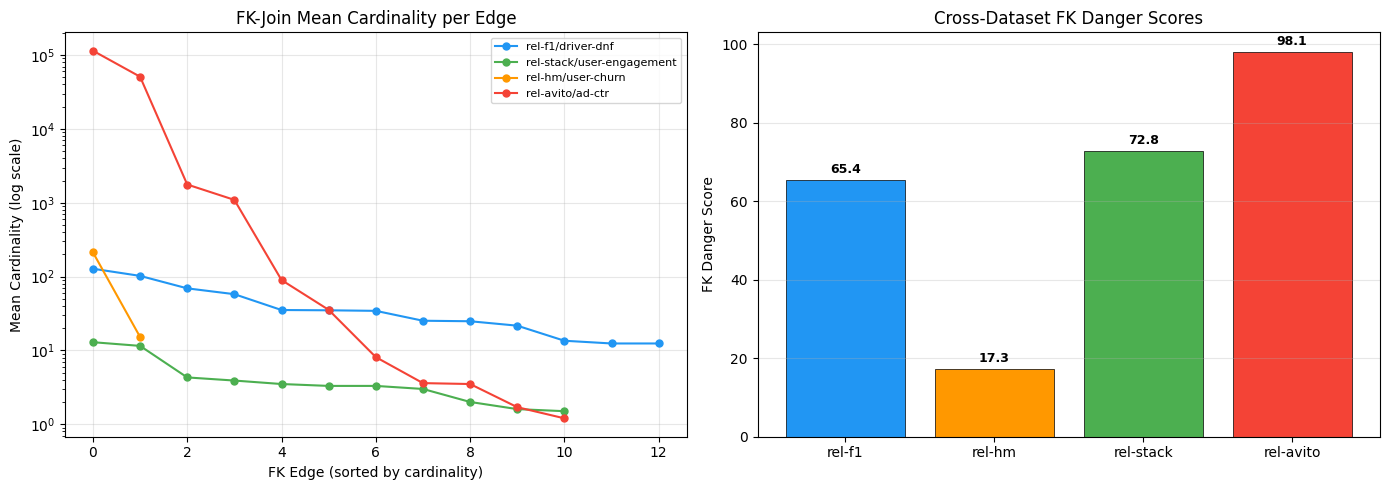

Saved: fk_cardinality_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean FK cardinality per edge (log scale) ---
ax1 = axes[0]
colors = {"rel-f1__driver-dnf": "#2196F3", "rel-stack__user-engagement": "#4CAF50",
          "rel-hm__user-churn": "#FF9800", "rel-avito__ad-ctr": "#F44336"}

for ds_name, edges in dataset_profiles.items():
    if not edges:
        continue
    means = [e["mean"] for e in edges]
    short_label = ds_name.replace("__", "/")
    color = colors.get(ds_name, "#999")
    # Sort by mean for cleaner plot
    means_sorted = sorted(means, reverse=True)
    ax1.plot(range(len(means_sorted)), means_sorted, 'o-', label=short_label,
             color=color, markersize=5, linewidth=1.5)

ax1.set_yscale("log")
ax1.set_xlabel("FK Edge (sorted by cardinality)")
ax1.set_ylabel("Mean Cardinality (log scale)")
ax1.set_title("FK-Join Mean Cardinality per Edge")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)

# --- Plot 2: FK Danger Scores ---
ax2 = axes[1]
ds_names_short = []
scores = []
bar_colors = []
color_map = {"rel-f1": "#2196F3", "rel-stack": "#4CAF50",
             "rel-hm": "#FF9800", "rel-avito": "#F44336"}

for ds_short in ["rel-f1", "rel-hm", "rel-stack", "rel-avito"]:
    score = danger_scores.get(ds_short, 0)
    ds_names_short.append(ds_short)
    scores.append(score)
    bar_colors.append(color_map.get(ds_short, "#999"))

bars = ax2.bar(ds_names_short, scores, color=bar_colors, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("FK Danger Score")
ax2.set_title("Cross-Dataset FK Danger Scores")
ax2.grid(True, alpha=0.3, axis="y")

# Add value labels on bars
for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{score:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("fk_cardinality_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: fk_cardinality_comparison.png")